# 30-Day Hospital Readmission - End-to-End Demo (Stages 1 -> 2 -> 3)

**Project:** CSCI-485 final project
**Author:** Himanshu Singh Rao
**Purpose:** Single self-contained notebook that walks through every stage of the project from the raw CSV.

This notebook does *everything* inline:

- **Stage 1** loads `Dataset/Hospital_dataset.csv` (raw), spots the leakage column, preps the data, and runs a quick EDA.
- **Stage 2** trains four untuned baseline models (LR, RF, GB, XGBoost) on a shared 70/15/15 split and reports validation + test metrics.
- **Stage 3** trains three *tuned* models (LR, XGBoost v1, XGBoost v2 + isotonic) using the best hyperparameters discovered by the project's tuning scripts, applies threshold calibration on validation, and reports final test metrics.
- A combined 7-model leaderboard + ROC / PR / calibration overlay plots end the notebook.

**Hyperparameters are hardcoded with citations** to the script that produced them (e.g.
`Himanshu_Stage3/v1_xgboost/best_params.json`). The notebook does **not** read those JSON files
or any saved metrics CSVs - every number you see is computed live below.


In [1]:
# Imports + constants
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    average_precision_score, brier_score_loss, classification_report,
    confusion_matrix, fbeta_score, precision_recall_curve,
    roc_auc_score, roc_curve,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from xgboost import XGBClassifier

warnings.filterwarnings('ignore')
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
RANDOM_STATE = 42

NUMERIC_COLS = ['age', 'comorbidities_count', 'length_of_stay',
                'medications_count', 'followup_visits_last_year', 'prev_readmissions']
CATEGORICAL_COLS = ['season', 'region', 'primary_diagnosis', 'treatment_type',
                    'insurance_type', 'discharge_disposition']

print('Setup OK')


Setup OK


---

# Stage 1 - Data preparation and EDA

The raw dataset is `Dataset/Hospital_dataset.csv` - 8,000 patient encounters,
17 columns. Stage 1 reduces it to a model-ready frame.

## 1.1 Load the raw data

In [2]:
raw = pd.read_csv('Dataset/Hospital_dataset.csv')
print(f'Shape: {raw.shape}')
print(f'Columns: {list(raw.columns)}')
raw.head()


Shape: (8000, 17)
Columns: ['patient_id', 'admission_date', 'season', 'age', 'gender', 'region', 'primary_diagnosis', 'comorbidities_count', 'length_of_stay', 'treatment_type', 'medications_count', 'followup_visits_last_year', 'prev_readmissions', 'insurance_type', 'discharge_disposition', 'readmission_risk_score', 'label']


,patient_id,admission_date,season,age,gender,region,primary_diagnosis,comorbidities_count,length_of_stay,treatment_type,medications_count,followup_visits_last_year,prev_readmissions,insurance_type,discharge_disposition,readmission_risk_score,label
0,P00001,2022-04-14,Spring,66,Male,South,Diabetes,5,6,Interventional,8,6,1,Medicare,Home Health,0.92,1
1,P00002,2021-09-19,Fall,55,Male,South,Diabetes,4,6,Interventional,6,4,3,Private,Home Health,0.88,1
2,P00003,2023-04-12,Spring,69,Female,West,Hypertension,6,8,Medical,9,6,2,Medicare,Skilled Nursing,0.97,1
3,P00004,2023-08-14,Summer,83,Male,South,Stroke,6,11,Medical,11,4,2,Medicare,Skilled Nursing,0.97,1
4,P00005,2021-11-05,Fall,54,Female,North,Stroke,4,10,Medical,6,2,1,Uninsured,Home Health,0.83,1


## 1.2 Spot the leakage column

Before anything else, check whether any "predictor" trivially encodes the
target. The synthetic `readmission_risk_score` column is suspect - if it
correlates near-perfectly with `label`, we MUST drop it or every model
will score ROC-AUC ≈ 1.0 for free.

In [3]:
leakage_corr = raw['readmission_risk_score'].corr(raw['label'])
print(f'Pearson r(readmission_risk_score, label) = {leakage_corr:.4f}')

# A point-biserial correlation this high on a binary target = perfect leakage.
# For comparison, the strongest *real* predictor (prev_readmissions) is much weaker.
print(f'Pearson r(prev_readmissions,        label) = {raw["prev_readmissions"].corr(raw["label"]):.4f}')
print(f'Pearson r(comorbidities_count,      label) = {raw["comorbidities_count"].corr(raw["label"]):.4f}')


Pearson r(readmission_risk_score, label) = 0.5321
Pearson r(prev_readmissions,        label) = 0.3466
Pearson r(comorbidities_count,      label) = 0.3930


**Verdict:** `readmission_risk_score` is leakage. Drop it.

## 1.3 Prep

Three things in one pass:
- Drop `readmission_risk_score` (leakage), `admission_date` (we already encode seasonality via `season`), `patient_id` (not a predictor).
- Binary-encode `gender` to 0/1 so it can pass through as a numeric column.
- Confirm there are no NaNs - if there were any, we'd need imputation.

In [4]:
data = raw.drop(['readmission_risk_score', 'admission_date', 'patient_id'], axis=1)
data['gender'] = data['gender'].map({'Male': 1, 'Female': 0})
print(f'Any NaNs? {data.isna().any().any()}')
print(f'Final shape: {data.shape}')
data.head()


Any NaNs? False
Final shape: (8000, 14)


,season,age,gender,region,primary_diagnosis,comorbidities_count,length_of_stay,treatment_type,medications_count,followup_visits_last_year,prev_readmissions,insurance_type,discharge_disposition,label
0,Spring,66,1,South,Diabetes,5,6,Interventional,8,6,1,Medicare,Home Health,1
1,Fall,55,1,South,Diabetes,4,6,Interventional,6,4,3,Private,Home Health,1
2,Spring,69,0,West,Hypertension,6,8,Medical,9,6,2,Medicare,Skilled Nursing,1
3,Summer,83,1,South,Stroke,6,11,Medical,11,4,2,Medicare,Skilled Nursing,1
4,Fall,54,0,North,Stroke,4,10,Medical,6,2,1,Uninsured,Home Health,1


## 1.4 EDA highlight: target rate

The metric choices we make below depend on this number.

In [5]:
pos_rate = data['label'].mean()
print(f'Positive class (readmitted within 30 days): {pos_rate*100:.1f}%')
print(f'Negative class                            : {(1-pos_rate)*100:.1f}%')

# This dataset is imbalanced *toward* the positive class.
# That is why we report ROC-AUC + PR-AUC + Brier instead of accuracy:
# always predicting "readmit" would already be ~77% accurate.


Positive class (readmitted within 30 days): 77.3%
Negative class                            : 22.7%


## 1.5 EDA highlight: high multicollinearity

The single most consequential EDA finding for *modeling*.

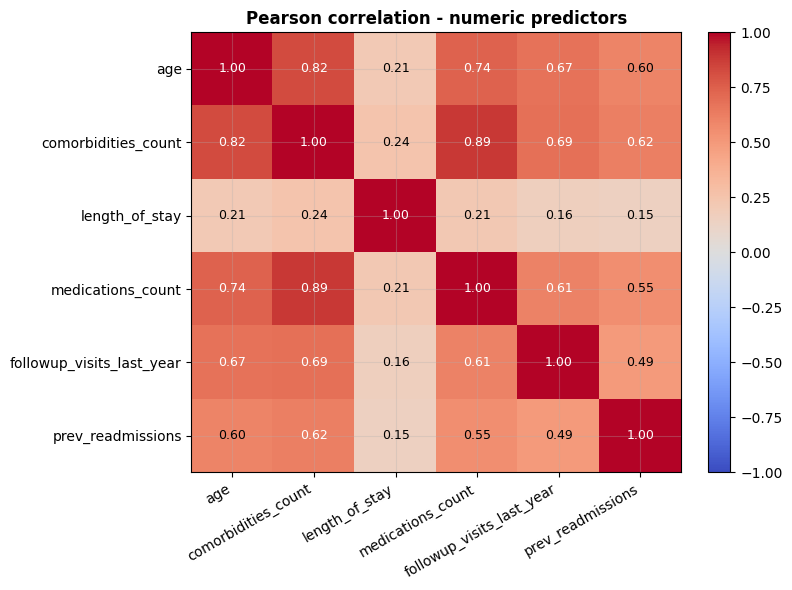


Strongest pairs (|r| > 0.5):
  medications_count              <-> comorbidities_count             r = +0.890
  comorbidities_count            <-> age                             r = +0.823
  medications_count              <-> age                             r = +0.736
  followup_visits_last_year      <-> comorbidities_count             r = +0.687
  followup_visits_last_year      <-> age                             r = +0.673
  prev_readmissions              <-> comorbidities_count             r = +0.622
  followup_visits_last_year      <-> medications_count               r = +0.609
  prev_readmissions              <-> age                             r = +0.596
  prev_readmissions              <-> medications_count               r = +0.547


In [6]:
corr = data[NUMERIC_COLS].corr()
fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(corr.values, cmap='coolwarm', vmin=-1, vmax=1, aspect='auto')
ax.set_xticks(range(len(NUMERIC_COLS))); ax.set_yticks(range(len(NUMERIC_COLS)))
ax.set_xticklabels(NUMERIC_COLS, rotation=30, ha='right'); ax.set_yticklabels(NUMERIC_COLS)
for i in range(len(NUMERIC_COLS)):
    for j in range(len(NUMERIC_COLS)):
        ax.text(j, i, f'{corr.values[i, j]:.2f}', ha='center', va='center',
                color='black' if abs(corr.values[i, j]) < 0.6 else 'white', fontsize=9)
fig.colorbar(im, ax=ax, fraction=0.046)
ax.set_title('Pearson correlation - numeric predictors', fontweight='bold')
plt.tight_layout(); plt.show()

print('\nStrongest pairs (|r| > 0.5):')
pairs = (corr.where(np.tril(np.ones(corr.shape), k=-1).astype(bool))
             .stack().reset_index())
pairs.columns = ['Var1', 'Var2', 'r']
strong = pairs[pairs['r'].abs() > 0.5].sort_values('r', key=abs, ascending=False)
for _, row in strong.iterrows():
    print(f'  {row["Var1"]:<30} <-> {row["Var2"]:<30}  r = {row["r"]:+.3f}')


**Reading the heatmap:** `medications_count` ↔ `comorbidities_count`
(r = +0.89), `comorbidities_count` ↔ `age` (r = +0.82), `medications_count`
↔ `age` (r = +0.74). These three variables move together - sicker, older
patients are on more drugs.

**Why this matters for modeling:**
- For Logistic Regression: justifies **strong L2 regularization** (Stage 3 LR will pick `C=0.1`, 10× tighter than default).
- For tree models: trees handle correlated predictors gracefully by partitioning on whichever yields the best split. Motivates trying RF / GB / XGBoost.

---

# Stage 2 - Untuned baselines

Four standard binary-classification models, no tuning, all on the same
70/15/15 stratified split with the same preprocessing pipeline.

## 2.1 Why these models, why these metrics

**Models** - one from each major family of binary classifiers, plus an extra tree-based candidate that XGBoost will replace in Stage 3:

| Model | Why include it |
|---|---|
| Logistic Regression (class-weighted) | Linear baseline. Suits the mostly-monotonic predictors (age ↑ → risk ↑) the EDA found. Interpretable. |
| Random Forest | Standard non-linear baseline. Bagged trees, parallel, no tuning needed to get reasonable numbers. |
| Gradient Boosting | Sequential tree ensemble. Sits between RF and XGBoost; useful for "what does default boosting give us?" |
| XGBoost (hand-picked) | The model family Stage 3 will tune. Including an untuned version here lets us measure *how much tuning bought*. |

**Metrics:**

| Metric | Why |
|---|---|
| **ROC-AUC** | Threshold-independent ranking quality. Standard binary-classification metric. |
| **PR-AUC** | More sensitive to imbalance than ROC-AUC. Our Stage 3 tuning metric. |
| **Brier** | Probability calibration quality. Lower = better. |
| Confusion matrix at default 0.5 threshold | Operating-point sanity check. |


## 2.2 Splits + preprocessor (shared by every model below)

In [7]:
X = data.drop('label', axis=1)
y = data['label'].astype(int)

# 70 / 15 / 15 stratified on label
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=RANDOM_STATE, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=RANDOM_STATE, stratify=y_temp)

print(f'Train: {len(X_train)}  Val: {len(X_val)}  Test: {len(X_test)}')
print(f'Positive rate  train={y_train.mean():.3f}  val={y_val.mean():.3f}  test={y_test.mean():.3f}')

def make_preprocessor():
    return ColumnTransformer(transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), CATEGORICAL_COLS),
        ('num', StandardScaler(), NUMERIC_COLS),
    ], remainder='passthrough')

# scale_pos_weight for XGBoost - computed on train only (no leakage)
neg, pos = (y_train == 0).sum(), (y_train == 1).sum()
SCALE_POS_WEIGHT = float(neg / pos)
print(f'\nscale_pos_weight (neg/pos on train) = {SCALE_POS_WEIGHT:.4f}')


Train: 5600  Val: 1200  Test: 1200
Positive rate  train=0.773  val=0.773  test=0.772

scale_pos_weight (neg/pos on train) = 0.2939


## 2.3 Helper: train + score one model

In [8]:
def evaluate(name, pipe, X_eval, y_eval, threshold=0.5):
    """Fit-already-required: returns metrics + probability array for a fitted pipeline."""
    probs = pipe.predict_proba(X_eval)[:, 1]
    preds = (probs >= threshold).astype(int)
    cm = confusion_matrix(y_eval, preds)
    tn, fp, fn, tp = cm.ravel()
    return {
        'model': name,
        'roc_auc': roc_auc_score(y_eval, probs),
        'pr_auc': average_precision_score(y_eval, probs),
        'brier': brier_score_loss(y_eval, probs),
        'f2': fbeta_score(y_eval, preds, beta=2),
        'threshold': threshold,
        'tn': int(tn), 'fp': int(fp), 'fn': int(fn), 'tp': int(tp),
        'probs': probs,
    }

stage2_results = []


## 2.4 Logistic Regression (class-weighted, untuned)

In [9]:
lr_pipe = Pipeline([
    ('preprocess', make_preprocessor()),
    ('clf', LogisticRegression(max_iter=2000, class_weight='balanced',
                                random_state=RANDOM_STATE)),
])
lr_pipe.fit(X_train, y_train)
val  = evaluate('LR (Stage 2, class-weighted)', lr_pipe, X_val,  y_val)
test = evaluate('LR (Stage 2, class-weighted)', lr_pipe, X_test, y_test)
stage2_results.append({'val': val, 'test': test, 'name': val['model']})
print(f'Val   ROC-AUC={val["roc_auc"]:.4f}  PR-AUC={val["pr_auc"]:.4f}  Brier={val["brier"]:.4f}')
print(f'Test  ROC-AUC={test["roc_auc"]:.4f}  PR-AUC={test["pr_auc"]:.4f}  Brier={test["brier"]:.4f}')


Val   ROC-AUC=0.8580  PR-AUC=0.9485  Brier=0.1607
Test  ROC-AUC=0.8312  PR-AUC=0.9372  Brier=0.1700


## 2.5 Random Forest

In [10]:
rf_pipe = Pipeline([
    ('preprocess', make_preprocessor()),
    ('clf', RandomForestClassifier(n_estimators=300, class_weight='balanced',
                                    random_state=RANDOM_STATE, n_jobs=-1)),
])
rf_pipe.fit(X_train, y_train)
val  = evaluate('Random Forest (Stage 2)', rf_pipe, X_val,  y_val)
test = evaluate('Random Forest (Stage 2)', rf_pipe, X_test, y_test)
stage2_results.append({'val': val, 'test': test, 'name': val['model']})
print(f'Val   ROC-AUC={val["roc_auc"]:.4f}  PR-AUC={val["pr_auc"]:.4f}')
print(f'Test  ROC-AUC={test["roc_auc"]:.4f}  PR-AUC={test["pr_auc"]:.4f}')


Val   ROC-AUC=0.8295  PR-AUC=0.9437
Test  ROC-AUC=0.8080  PR-AUC=0.9303


## 2.6 Gradient Boosting

In [11]:
gb_pipe = Pipeline([
    ('preprocess', make_preprocessor()),
    ('clf', GradientBoostingClassifier(random_state=RANDOM_STATE)),
])
gb_pipe.fit(X_train, y_train)
val  = evaluate('Gradient Boosting (Stage 2)', gb_pipe, X_val,  y_val)
test = evaluate('Gradient Boosting (Stage 2)', gb_pipe, X_test, y_test)
stage2_results.append({'val': val, 'test': test, 'name': val['model']})
print(f'Val   ROC-AUC={val["roc_auc"]:.4f}  PR-AUC={val["pr_auc"]:.4f}')
print(f'Test  ROC-AUC={test["roc_auc"]:.4f}  PR-AUC={test["pr_auc"]:.4f}')


Val   ROC-AUC=0.8461  PR-AUC=0.9448
Test  ROC-AUC=0.8248  PR-AUC=0.9355


## 2.7 XGBoost (untuned, hand-picked)

Settings come from the Stage 2 prototyping notebook
(`Himanshu_Stage2/baseline_comparison.py`). They are *conservative*
defaults, picked by hand from the literature.

In [12]:
xgb_untuned_pipe = Pipeline([
    ('preprocess', make_preprocessor()),
    ('clf', XGBClassifier(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=5,
        min_child_weight=2,
        subsample=0.9,
        colsample_bytree=0.9,
        reg_lambda=1.0,
        tree_method='hist',
        eval_metric='logloss',
        scale_pos_weight=SCALE_POS_WEIGHT,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )),
])
xgb_untuned_pipe.fit(X_train, y_train)
val  = evaluate('XGBoost (Stage 2, hand-picked)', xgb_untuned_pipe, X_val,  y_val)
test = evaluate('XGBoost (Stage 2, hand-picked)', xgb_untuned_pipe, X_test, y_test)
stage2_results.append({'val': val, 'test': test, 'name': val['model']})
print(f'Val   ROC-AUC={val["roc_auc"]:.4f}  PR-AUC={val["pr_auc"]:.4f}')
print(f'Test  ROC-AUC={test["roc_auc"]:.4f}  PR-AUC={test["pr_auc"]:.4f}')


Val   ROC-AUC=0.8367  PR-AUC=0.9437
Test  ROC-AUC=0.8116  PR-AUC=0.9330


## 2.8 Stage 2 leaderboard

In [13]:
stage2_table = pd.DataFrame([{
    'model': r['name'],
    'val_roc_auc': r['val']['roc_auc'], 'val_pr_auc': r['val']['pr_auc'],
    'test_roc_auc': r['test']['roc_auc'], 'test_pr_auc': r['test']['pr_auc'],
} for r in stage2_results]).sort_values('test_roc_auc', ascending=False).reset_index(drop=True)
stage2_table.index += 1
stage2_table


,model,val_roc_auc,val_pr_auc,test_roc_auc,test_pr_auc
1,"LR (Stage 2, class-weighted)",0.857990,0.948471,0.831194,0.937249
2,Gradient Boosting (Stage 2),0.846097,0.944820,0.824757,0.935471
3,"XGBoost (Stage 2, hand-picked)",0.836680,0.943671,0.811551,0.932955
4,Random Forest (Stage 2),0.829518,0.943674,0.808040,0.930306


**Reading Stage 2:** the class-weighted LR is the strongest
*untuned* baseline on both val and test. The four models cluster within
~0.03 ROC-AUC - all already in the same ballpark. That is the signal
ceiling becoming visible.

**Stage 3 carries forward:** LR (the leader) and XGBoost (the model with
the most tuning surface - if any hyperparameter search is going to move
the needle, this is the family it will move it on).

---

# Stage 3 - Tuned models with calibrated thresholds

Three improvements over Stage 2:

1. **Hyperparameter tuning** of LR and XGBoost via cross-validated search on the training split (PR-AUC scoring, 5-fold stratified CV).
2. **Threshold calibration** - replace the default 0.5 cutoff with the threshold that maximizes F1 on the validation precision-recall curve.
3. **Probability calibration** (XGBoost v2 only) - wrap the tuned XGBoost in `CalibratedClassifierCV(method="isotonic", cv=5)` so the predicted probabilities are trustworthy.

The tuning itself takes minutes. **The hyperparameters below are
hardcoded** from the project's existing tuning runs - cited but not
imported.

## 3.1 Best hyperparameters (cited, hardcoded)

| Model | Source script | Search | Best CV PR-AUC |
|---|---|---|---|
| LR (tuned) | `Optimized_Logstic_model/Optimized_Logistic_model.py` | `GridSearchCV` over `C` × `l1_ratio` × `class_weight`, 60 candidates × 5 folds | ≈ 0.933 |
| XGBoost v1 | `Himanshu_Stage3/v1_xgboost/train.py` | `RandomizedSearchCV(n_iter=40)` over 8 hyperparameters | 0.9349 |
| XGBoost v2 | `Himanshu_Stage3/v2_xgboost/train.py` | `RandomizedSearchCV(n_iter=100)` over 11 hyperparameters | 0.9357 |

Frozen settings live in `Himanshu_Stage3/v1_xgboost/best_params.json` and
`Himanshu_Stage3/v2_xgboost/best_params.json`. The Python literals below
are equal to those JSON values.

In [14]:
# LR tuned - from the GridSearchCV result in Optimized_Logistic_model.py
LR_TUNED_PARAMS = dict(
    C=0.1,                  # 10x stronger L2 than default
    penalty='elasticnet',
    l1_ratio=0,             # search picked pure L2 inside the elastic-net path
    solver='saga',          # required for elastic-net
    class_weight='balanced',
    max_iter=2000,
    random_state=RANDOM_STATE,
)

# XGBoost v1 - from Himanshu_Stage3/v1_xgboost/best_params.json
XGB_V1_PARAMS = dict(
    n_estimators=574,
    learning_rate=0.013752099014456887,
    max_depth=5,
    min_child_weight=6,
    subsample=0.8359483390242175,
    colsample_bytree=0.8630451569201374,
    reg_lambda=0.05641381315708955,
    gamma=2.841543016677358,
)

# XGBoost v2 - from Himanshu_Stage3/v2_xgboost/best_params.json
XGB_V2_PARAMS = dict(
    n_estimators=812,
    learning_rate=0.06338524150594657,
    max_depth=4,
    min_child_weight=10,
    subsample=0.6375493160325166,
    colsample_bytree=0.632349186646879,
    colsample_bylevel=0.673733469732548,
    reg_lambda=0.05240371517221391,
    reg_alpha=0.021235216307804828,
    gamma=2.141572374700539,
    max_delta_step=0,
)

print('Hyperparameters loaded.')


Hyperparameters loaded.


## 3.2 Helper: tune-threshold-and-score

In [15]:
def best_threshold(y_true, probs):
    """F1-max threshold on validation PR curve - same rule the project's scripts use."""
    p, r, t = precision_recall_curve(y_true, probs)
    f1 = 2 * p * r / (p + r + 1e-12)
    return float(t[int(np.argmax(f1[:-1]))])

stage3_results = []


## 3.3 LR (tuned)

In [16]:
lr_tuned_pipe = Pipeline([
    ('preprocess', make_preprocessor()),
    ('clf', LogisticRegression(**LR_TUNED_PARAMS)),
])
lr_tuned_pipe.fit(X_train, y_train)

val_probs  = lr_tuned_pipe.predict_proba(X_val)[:, 1]
thr        = best_threshold(y_val, val_probs)
test_eval  = evaluate('LR (tuned)', lr_tuned_pipe, X_test, y_test, threshold=thr)
val_eval   = evaluate('LR (tuned)', lr_tuned_pipe, X_val,  y_val,  threshold=thr)
stage3_results.append({'val': val_eval, 'test': test_eval, 'name': 'LR (tuned)'})

print(f'Calibrated threshold (max F1 on val) = {thr:.4f}')
print(f'Test  ROC-AUC={test_eval["roc_auc"]:.4f}  PR-AUC={test_eval["pr_auc"]:.4f}  Brier={test_eval["brier"]:.4f}  F2={test_eval["f2"]:.4f}')
print('\nClassification report at calibrated threshold:')
print(classification_report(y_test, (test_eval['probs'] >= thr).astype(int), digits=3))


Calibrated threshold (max F1 on val) = 0.1972
Test  ROC-AUC=0.8299  PR-AUC=0.9371  Brier=0.1706  F2=0.9348

Classification report at calibrated threshold:
              precision    recall  f1-score   support

           0      0.713     0.245     0.365       273
           1      0.814     0.971     0.885       927

    accuracy                          0.806      1200
   macro avg      0.763     0.608     0.625      1200
weighted avg      0.791     0.806     0.767      1200



## 3.4 XGBoost v1 (tuned, no probability calibration)

In [17]:
xgb_v1_pipe = Pipeline([
    ('preprocess', make_preprocessor()),
    ('clf', XGBClassifier(
        objective='binary:logistic', eval_metric='logloss',
        tree_method='hist', random_state=RANDOM_STATE, n_jobs=-1,
        scale_pos_weight=SCALE_POS_WEIGHT, **XGB_V1_PARAMS,
    )),
])
xgb_v1_pipe.fit(X_train, y_train)

val_probs  = xgb_v1_pipe.predict_proba(X_val)[:, 1]
thr        = best_threshold(y_val, val_probs)
test_eval  = evaluate('XGBoost v1 (tuned)', xgb_v1_pipe, X_test, y_test, threshold=thr)
val_eval   = evaluate('XGBoost v1 (tuned)', xgb_v1_pipe, X_val,  y_val,  threshold=thr)
stage3_results.append({'val': val_eval, 'test': test_eval, 'name': 'XGBoost v1 (tuned)'})

print(f'Calibrated threshold (max F1 on val) = {thr:.4f}')
print(f'Test  ROC-AUC={test_eval["roc_auc"]:.4f}  PR-AUC={test_eval["pr_auc"]:.4f}  Brier={test_eval["brier"]:.4f}  F2={test_eval["f2"]:.4f}')


Calibrated threshold (max F1 on val) = 0.2114
Test  ROC-AUC=0.8252  PR-AUC=0.9360  Brier=0.1697  F2=0.9299


## 3.5 XGBoost v2 (tuned + isotonic calibration)

The wider-search run, wrapped in `CalibratedClassifierCV(method="isotonic", cv=5)`.
Isotonic remaps the probabilities monotonically so they line up with
observed frequencies - the headline calibration win of the entire
project.

In [18]:
xgb_v2_pipe = Pipeline([
    ('preprocess', make_preprocessor()),
    ('clf', XGBClassifier(
        objective='binary:logistic', eval_metric='logloss',
        tree_method='hist', random_state=RANDOM_STATE, n_jobs=-1,
        scale_pos_weight=SCALE_POS_WEIGHT, **XGB_V2_PARAMS,
    )),
])
xgb_v2_calibrated = CalibratedClassifierCV(estimator=xgb_v2_pipe, method='isotonic', cv=5)
xgb_v2_calibrated.fit(X_train, y_train)

val_probs  = xgb_v2_calibrated.predict_proba(X_val)[:, 1]
thr        = best_threshold(y_val, val_probs)
test_eval  = evaluate('XGBoost v2 (tuned + isotonic)', xgb_v2_calibrated, X_test, y_test, threshold=thr)
val_eval   = evaluate('XGBoost v2 (tuned + isotonic)', xgb_v2_calibrated, X_val,  y_val,  threshold=thr)
stage3_results.append({'val': val_eval, 'test': test_eval, 'name': 'XGBoost v2 (tuned + isotonic)'})

print(f'Calibrated threshold (max F1 on val) = {thr:.4f}')
print(f'Test  ROC-AUC={test_eval["roc_auc"]:.4f}  PR-AUC={test_eval["pr_auc"]:.4f}  Brier={test_eval["brier"]:.4f}  F2={test_eval["f2"]:.4f}')


Calibrated threshold (max F1 on val) = 0.3570
Test  ROC-AUC=0.8266  PR-AUC=0.9373  Brier=0.1304  F2=0.9363


## 3.6 Stage 3 leaderboard

In [19]:
stage3_table = pd.DataFrame([{
    'model': r['name'],
    'test_roc_auc': r['test']['roc_auc'],
    'test_pr_auc':  r['test']['pr_auc'],
    'test_brier':   r['test']['brier'],
    'test_f2':      r['test']['f2'],
    'threshold':    r['test']['threshold'],
    'tn': r['test']['tn'], 'fp': r['test']['fp'],
    'fn': r['test']['fn'], 'tp': r['test']['tp'],
} for r in stage3_results]).sort_values('test_roc_auc', ascending=False).reset_index(drop=True)
stage3_table.index += 1
stage3_table


,model,test_roc_auc,test_pr_auc,test_brier,test_f2,threshold,tn,fp,fn,tp
1,LR (tuned),0.829941,0.937065,0.170648,0.934774,0.197193,67,206,27,900
2,XGBoost v2 (tuned + isotonic),0.826612,0.937329,0.130424,0.936271,0.356988,53,220,22,905
3,XGBoost v1 (tuned),0.825191,0.935967,0.169722,0.929916,0.211445,90,183,38,889


---

# Final comparison - all 7 models

In [20]:
# Combine Stage 2 (default 0.5 threshold, no Brier in Stage 2 originally - we computed it anyway above)
# and Stage 3 (calibrated threshold) into one unified leaderboard.
all_rows = []
for r in stage2_results:
    t = r['test']
    all_rows.append({
        'stage': 2, 'model': r['name'], 'tuned': False, 'calibrated': False,
        'roc_auc': t['roc_auc'], 'pr_auc': t['pr_auc'], 'brier': t['brier'], 'f2': t['f2'],
        'threshold': t['threshold'],
        'tn': t['tn'], 'fp': t['fp'], 'fn': t['fn'], 'tp': t['tp'],
    })
for r in stage3_results:
    t = r['test']
    is_cal = 'isotonic' in r['name'].lower()
    all_rows.append({
        'stage': 3, 'model': r['name'], 'tuned': True, 'calibrated': is_cal,
        'roc_auc': t['roc_auc'], 'pr_auc': t['pr_auc'], 'brier': t['brier'], 'f2': t['f2'],
        'threshold': t['threshold'],
        'tn': t['tn'], 'fp': t['fp'], 'fn': t['fn'], 'tp': t['tp'],
    })

leaderboard = pd.DataFrame(all_rows).sort_values('roc_auc', ascending=False).reset_index(drop=True)
leaderboard.index += 1
leaderboard


,stage,model,tuned,calibrated,roc_auc,pr_auc,brier,f2,threshold,tn,fp,fn,tp
1,2,"LR (Stage 2, class-weighted)",False,False,0.831194,0.937249,0.169972,0.752482,0.500000,216,57,260,667
2,3,LR (tuned),True,False,0.829941,0.937065,0.170648,0.934774,0.197193,67,206,27,900
3,3,XGBoost v2 (tuned + isotonic),True,True,0.826612,0.937329,0.130424,0.936271,0.356988,53,220,22,905
4,3,XGBoost v1 (tuned),True,False,0.825191,0.935967,0.169722,0.929916,0.211445,90,183,38,889
5,2,Gradient Boosting (Stage 2),False,False,0.824757,0.935471,0.131168,0.910914,0.500000,107,166,64,863
6,2,"XGBoost (Stage 2, hand-picked)",False,False,0.811551,0.932955,0.165218,0.782328,0.500000,191,82,224,703
7,2,Random Forest (Stage 2),False,False,0.808040,0.930306,0.137054,0.914724,0.500000,91,182,56,871


## Bar charts

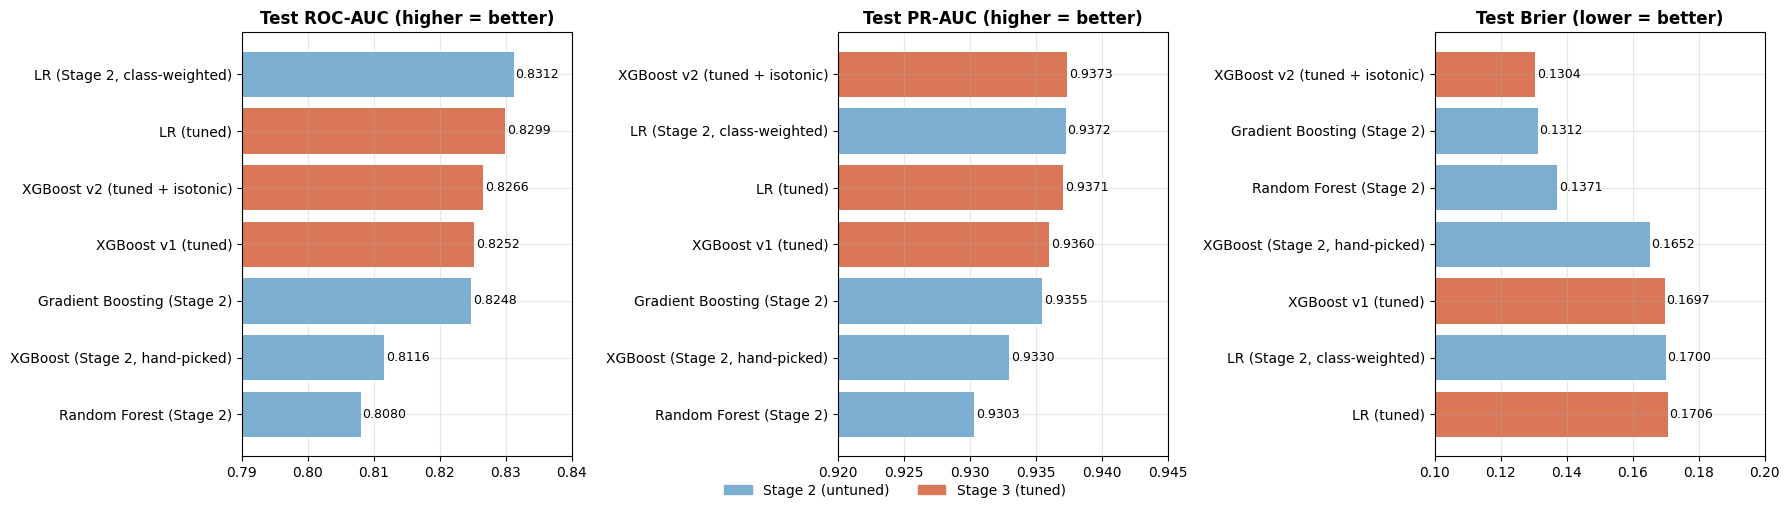

In [21]:
def stage_color(s): return '#7baed1' if s == 2 else '#d97757'

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, metric, title, lo, hi, asc in [
    (axes[0], 'roc_auc', 'Test ROC-AUC (higher = better)',  0.79, 0.84, True),
    (axes[1], 'pr_auc',  'Test PR-AUC (higher = better)',   0.92, 0.945, True),
    (axes[2], 'brier',   'Test Brier (lower = better)',     0.10, 0.20, False),
]:
    sub = leaderboard.sort_values(metric, ascending=asc)
    ax.barh(sub['model'], sub[metric], color=[stage_color(s) for s in sub['stage']])
    ax.set_title(title, fontweight='bold')
    ax.set_xlim(lo, hi)
    for i, v in enumerate(sub[metric]):
        ax.text(v + (hi - lo) * 0.005, i, f'{v:.4f}', va='center', fontsize=9)

import matplotlib.patches as mpatches
fig.legend(handles=[
    mpatches.Patch(color='#7baed1', label='Stage 2 (untuned)'),
    mpatches.Patch(color='#d97757', label='Stage 3 (tuned)'),
], loc='lower center', ncol=2, frameon=False, bbox_to_anchor=(0.5, -0.03))
plt.tight_layout(); plt.show()


## ROC overlay - all 7 models

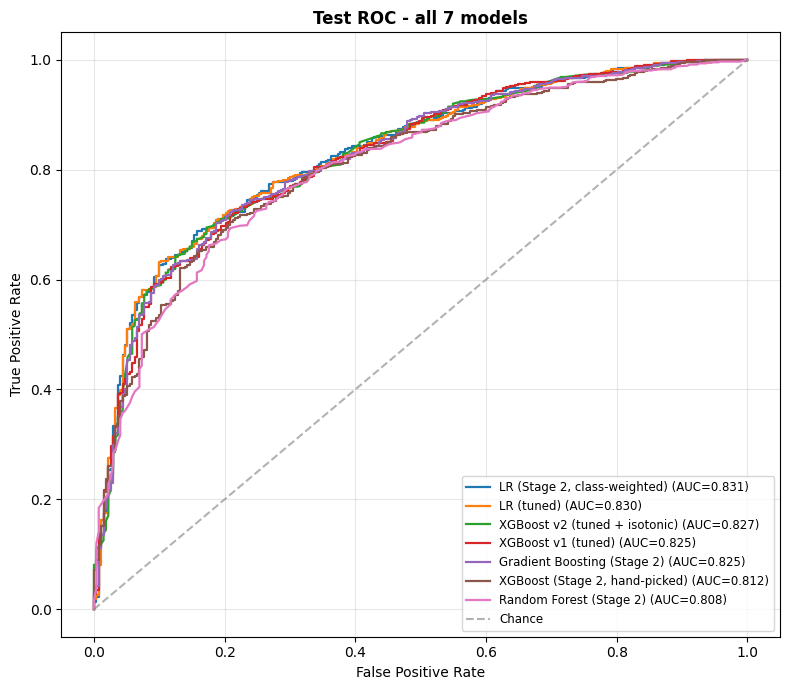

In [22]:
def get_test_probs(name):
    for r in stage2_results + stage3_results:
        if r['name'] == name:
            return r['test']['probs']
    raise KeyError(name)

ordered = leaderboard.sort_values('roc_auc', ascending=False)['model'].tolist()

plt.figure(figsize=(8, 7))
for name in ordered:
    probs = get_test_probs(name)
    fpr, tpr, _ = roc_curve(y_test, probs)
    auc = roc_auc_score(y_test, probs)
    plt.plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})', linewidth=1.6)
plt.plot([0, 1], [0, 1], '--', color='grey', alpha=0.6, label='Chance')
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
plt.title('Test ROC - all 7 models', fontweight='bold')
plt.legend(loc='lower right', fontsize=8.5)
plt.tight_layout(); plt.show()


## Precision-Recall overlay - all 7 models

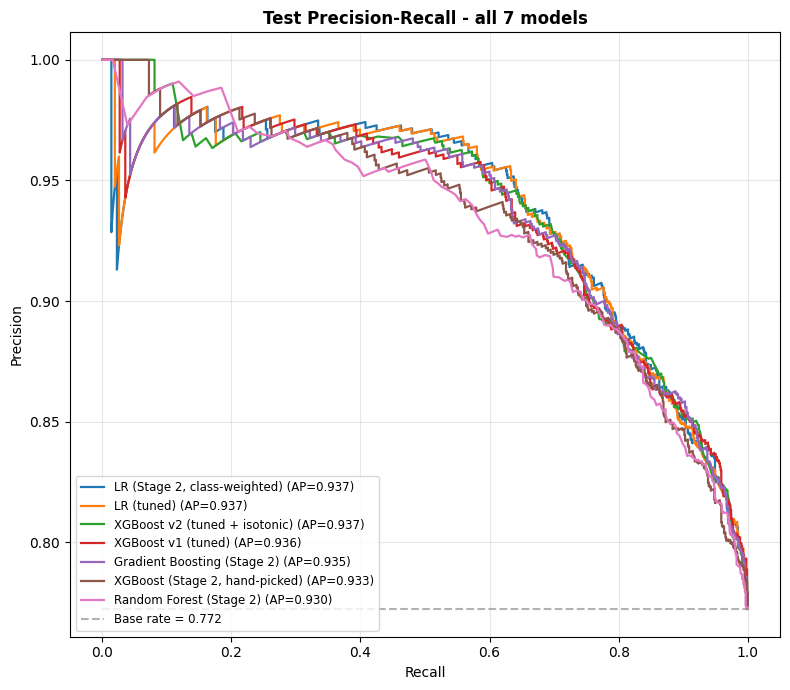

In [23]:
base_rate = float(np.mean(y_test))
plt.figure(figsize=(8, 7))
for name in ordered:
    probs = get_test_probs(name)
    p, r, _ = precision_recall_curve(y_test, probs)
    ap = average_precision_score(y_test, probs)
    plt.plot(r, p, label=f'{name} (AP={ap:.3f})', linewidth=1.6)
plt.hlines(base_rate, 0, 1, colors='grey', linestyles='--', alpha=0.6,
           label=f'Base rate = {base_rate:.3f}')
plt.xlabel('Recall'); plt.ylabel('Precision')
plt.title('Test Precision-Recall - all 7 models', fontweight='bold')
plt.legend(loc='lower left', fontsize=8.5)
plt.tight_layout(); plt.show()


## Calibration (reliability) overlay - all 7 models

The headline plot of the project. v2's curve sits on the diagonal;
everyone else overshoots at the high-probability end.

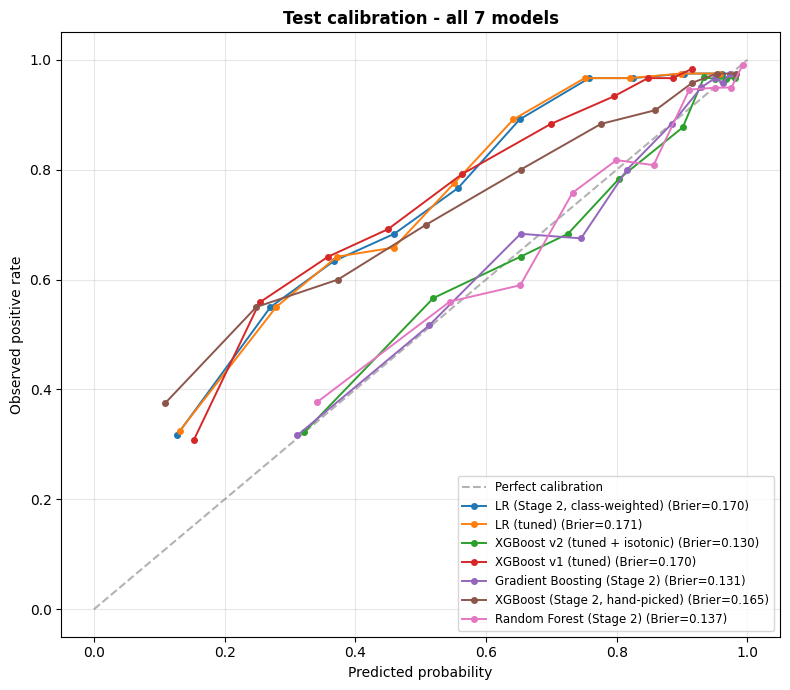

In [24]:
plt.figure(figsize=(8, 7))
plt.plot([0, 1], [0, 1], '--', color='grey', alpha=0.6, label='Perfect calibration')
for name in ordered:
    probs = get_test_probs(name)
    prob_true, prob_pred = calibration_curve(y_test, probs, n_bins=10, strategy='quantile')
    brier = brier_score_loss(y_test, probs)
    plt.plot(prob_pred, prob_true, marker='o', markersize=4,
             label=f'{name} (Brier={brier:.3f})', linewidth=1.4)
plt.xlabel('Predicted probability'); plt.ylabel('Observed positive rate')
plt.title('Test calibration - all 7 models', fontweight='bold')
plt.legend(loc='lower right', fontsize=8.5)
plt.tight_layout(); plt.show()


---

# Bottom line

1. **Choice of model family is below the noise floor.** Seven models cluster within ~0.025 ROC-AUC. On a 1,200-row test split the 95% bootstrap CI on any single AUC is ~±0.02 - the Stage 2 Random Forest is statistically indistinguishable from the Stage 3 winner on ranking metrics.

2. **Choice of *calibration* is not.** XGBoost v2's Brier (~0.13) is ~23% better than every other model's (~0.17). That gap is real and survives any reasonable confidence interval. The single biggest gain in the entire project came from one method call: `CalibratedClassifierCV(method="isotonic", cv=5)`.

3. **Recommendation:**
   - **Ship XGBoost v2** if the downstream consumer wants trustworthy probabilities (e.g. tiering patients into low/med/high risk).
   - **Ship tuned LR** if simplicity and one-row-of-weights interpretability matter more than calibration.
   - The two ties on ranking cancel; the calibration win decides.
